In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_8K_pbmc_citeseq',
    destination='scarf_datasets',
    zarr=True,
)

PosixPath('/tmp/tmpktu2pjh3/scarf_datasets/tenx_8K_pbmc_citeseq')

In [3]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    default_assay='RNA',
    nthreads=4
)

In [4]:
ds

DataStore has 7549 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'ADT_nFeatures', 
            'RNA_tSNE2', 'ADT_UMAP2', 'RNA_tSNE1', 'ADT_UMAP1', 'RNA_nFeatures', 
            'RNA_percentRibo', 'ADT_nCounts', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_cluster', 
            'ADT_leiden_cluster', 'RNA_UMAP2', 'RNA_UMAP1'
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [5]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,False,7865
1,False,ENSG00000237613,FAM138A,0,False,7865
2,False,ENSG00000186092,OR4F5,0,False,7865
3,False,ENSG00000238009,AL627309.1,12,False,7853
4,False,ENSG00000239945,AL627309.3,0,False,7865


In [6]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


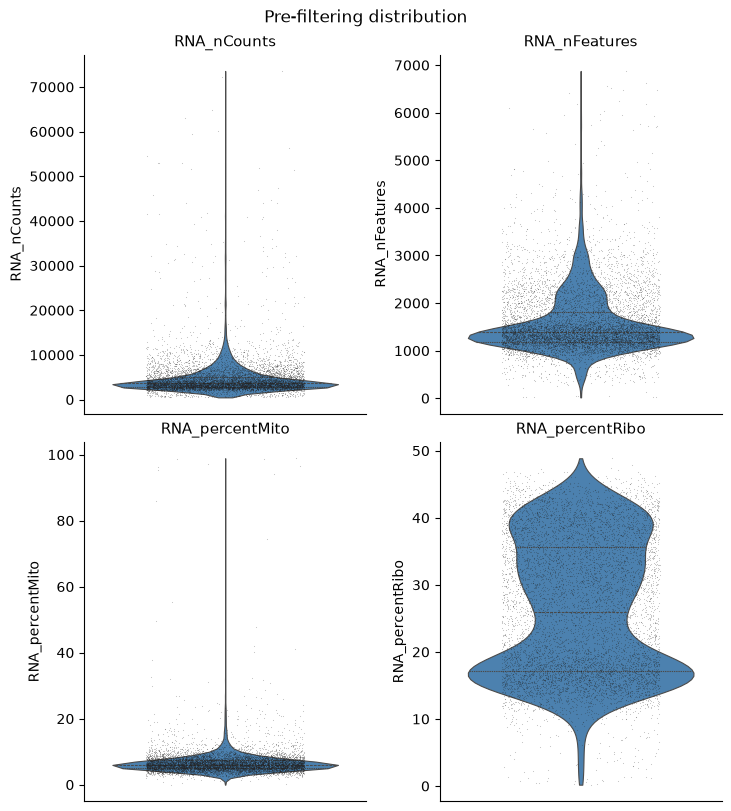

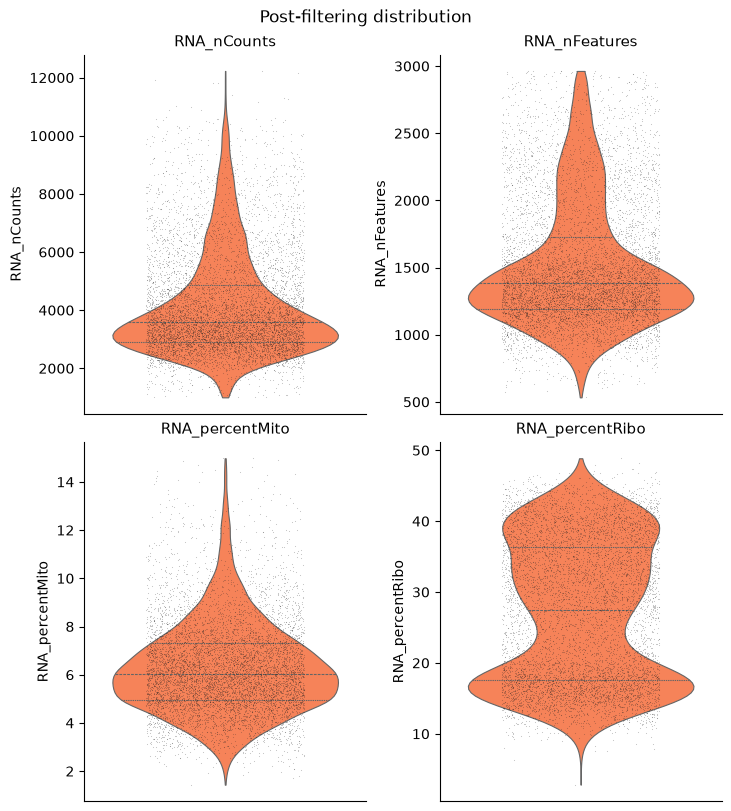

In [7]:
ds.auto_filter_cells()

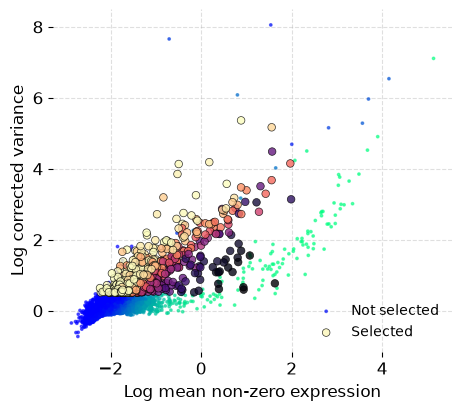

In [8]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6
)

normalized = ds.run_normalization(feat_key='hvgs')
pca = ds.run_pca(normalized, dims=15)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(resolution=1)

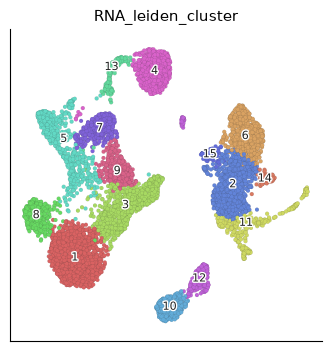

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [9]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [10]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


In [11]:
adt_names = ds.ADT.feats.to_pandas_dataframe(['names'])['names']
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

In [12]:
is_control = adt_names.str.contains('control').values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

In [13]:
ds.ADT.feats.update_key(~is_control, 'I')
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,dropOuts,nCells
0,True,CD3,CD3_TotalSeqB,1,7864
1,True,CD4,CD4_TotalSeqB,1,7864
2,True,CD8a,CD8a_TotalSeqB,2,7863
3,True,CD14,CD14_TotalSeqB,1,7864
4,True,CD15,CD15_TotalSeqB,1,7864
5,True,CD16,CD16_TotalSeqB,1,7864
6,True,CD56,CD56_TotalSeqB,1,7864
7,True,CD19,CD19_TotalSeqB,163,7702
8,True,CD25,CD25_TotalSeqB,4,7861
9,True,CD45RA,CD45RA_TotalSeqB,1,7864


In [14]:
print (ds.ADT)
print (ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr


In [15]:
ds.make_graph(
    from_assay='ADT',
    feat_key='I', 
    k=21,
    dims=0,
    n_centroids=100
)

/tmp/ipykernel_604086/4276686665.py:1: DeprecationWarning: make_graph is deprecated; call the atomic graph methods instead.
  ds.make_graph(


In [16]:
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1
)

In [17]:
ds.cells.head()

,I,ids,names,ADT_nFeatures,RNA_percentMito,RNA_tSNE2,ADT_UMAP2,ADT_UMAP1,RNA_tSNE1,RNA_nFeatures,RNA_nCounts,RNA_percentRibo,RNA_cluster,ADT_nCounts,RNA_leiden_cluster,RNA_UMAP2,RNA_UMAP1,ADT_leiden_cluster
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,17.0,8.668831,-18.08830,-14.750116,-24.649570,-4.26865,2194.0,6160.0,15.259740,4,981.0,6,11.060140,24.364742,4
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,17.0,6.316103,-14.88920,-5.198872,-17.447691,5.02671,2093.0,6713.0,19.037688,4,1475.0,6,12.451416,26.886850,14
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,17.0,8.056090,-18.83030,-6.003889,-20.531944,-14.91320,1518.0,3637.0,16.002200,5,7149.0,2,-0.489377,19.385298,4
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,17.0,9.003215,-3.35003,-20.963287,23.325235,16.69630,737.0,1244.0,18.729904,3,6831.0,4,29.510477,3.202080,2
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,17.0,6.204519,-1.37607,-22.891804,24.259653,18.37000,1240.0,2611.0,16.353887,3,6839.0,4,30.079519,-4.148618,2


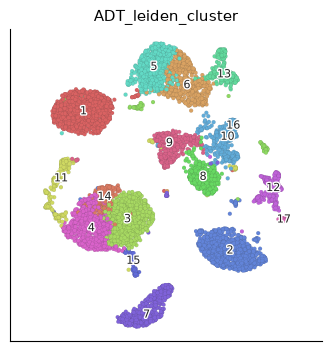

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [18]:
ds.plots.embedding(
    layout_key='ADT_UMAP',
    color_by='ADT_leiden_cluster',
)

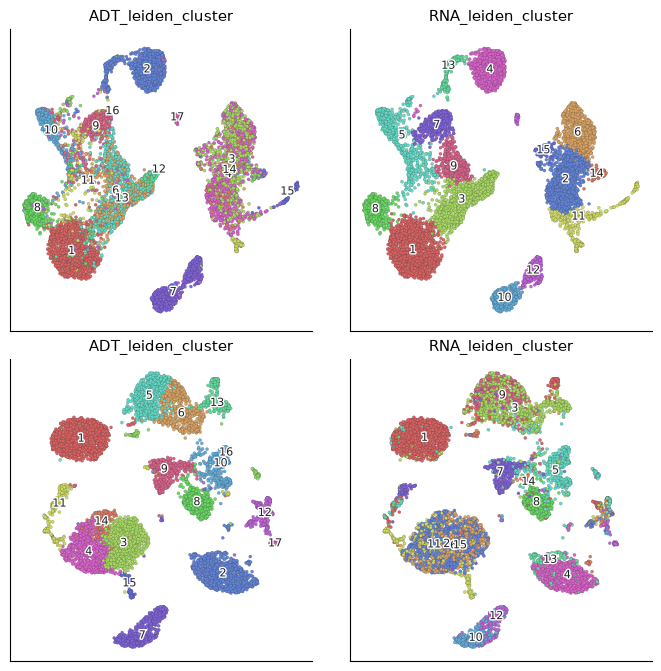

PlotResult(axes=4, tables=0, legends=4, scales=3, owns_figure=True, rendered=True)

In [19]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by=['ADT_leiden_cluster', 'RNA_leiden_cluster'],
    n_columns=2,
    point_size=5,
    legend_loc='on_data',
)

In [20]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch('RNA_leiden_cluster'),
    ds.cells.fetch('ADT_leiden_cluster')
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
row_0,,,,,,,,,,,,,,,,,
1,1025,0,0,0,43,21,0,24,2,2,30,18,64,0,0,0,0
2,0,0,422,381,0,2,1,0,0,2,0,28,0,85,0,3,0
3,25,0,0,0,333,315,0,2,8,15,12,15,142,0,0,0,0
4,0,721,0,0,0,0,0,0,1,1,0,24,0,0,0,3,0
5,17,6,0,0,4,54,1,37,66,307,45,35,2,0,0,28,0
6,0,0,322,210,0,2,0,1,1,0,1,17,1,39,0,4,0
7,0,0,0,0,16,3,0,5,320,3,76,12,0,0,0,0,0
8,6,0,0,0,0,0,0,346,5,7,8,4,0,0,0,0,0
9,1,0,0,0,180,123,0,1,7,8,9,15,1,0,0,1,0


In [21]:
(100 * df.max()/df.sum()).sort_values(ascending=False)

col_0
17    100.000000
1      95.437616
15     94.520548
10     87.965616
8      80.652681
2      80.558659
9      77.108434
13     67.298578
7      61.153846
14     59.859155
6      59.659091
5      57.712305
4      52.551724
3      50.721154
16     45.161290
11     31.147541
12     14.830508
dtype: float64

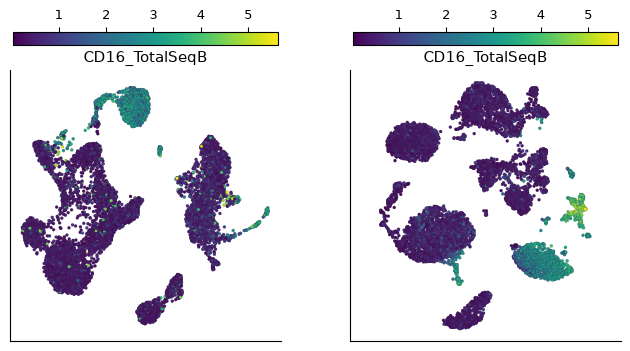

PlotResult(axes=2, tables=0, legends=2, scales=1, owns_figure=True, rendered=True)

In [22]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='CD16_TotalSeqB',
    from_assay='ADT',
    n_columns=2,
    point_size=5,
)

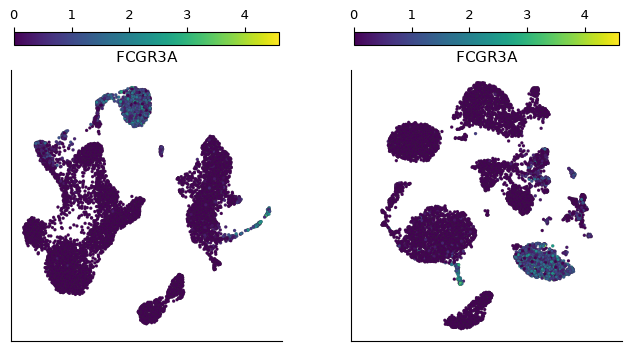

PlotResult(axes=2, tables=0, legends=2, scales=1, owns_figure=True, rendered=True)

In [23]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='FCGR3A',
    from_assay='RNA',
    n_columns=2,
    point_size=5,
)